In [1]:
import torch
import random
import time
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as transforms
from skimage.color import rgb2lab, lab2rgb
from PIL import Image
from fastai.vision.learner import create_body
from fastai.vision.models.unet import DynamicUnet
import yaml

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
experiment = 'simple-unet-shufflenet_v2_x1_5-2024-06-23-18:55:04'

In [4]:
experiment_path = f'./experiments/{experiment}'

with open(f'{experiment_path}/config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [5]:
ACTIVATION_FUNCTION = config["ACTIVATION_FUNCTION"]
BACKBONE = config["BACKBONE"]
DATASET_PATH = config["DATASET_PATH"]
IMAGE_SIZE = config["IMAGE_SIZE"]
SELF_ATTENTION = config["SELF_ATTENTION"]
EXPERIMENT_NAME = config['EXPERIMENT_NAME']
ACTIVATION_FUNCTION = config['ACTIVATION_FUNCTION']

In [6]:
def build_model(backbone, n_input=1, n_output=2, size=256):

    if backbone == 'resnet18':
        backbone = models.resnet18(weights='DEFAULT')
    
    elif backbone == 'resnet34':
        backbone = models.resnet34(weights='DEFAULT')
    
    elif backbone == 'convnext_tiny':
        backbone = models.convnext_tiny(weights='DEFAULT')

    elif backbone == 'efficientnet_v2_s':
        backbone = models.efficientnet_v2_s(weights='DEFAULT')

    elif backbone == 'shufflenet_v2_x0_5':
        backbone = models.shufflenet_v2_x2_0(weights='DEFAULT')

    elif backbone == 'shufflenet_v2_x1_0':
        backbone = models.shufflenet_v2_x2_0(weights='DEFAULT')

    elif backbone == 'shufflenet_v2_x1_5':
        backbone = models.shufflenet_v2_x2_0(weights='DEFAULT')

    elif backbone == 'shufflenet_v2_x2_0':
        backbone = models.shufflenet_v2_x2_0(weights='DEFAULT')
  
    body = create_body(backbone, n_in=n_input, pretrained=True, cut=-2) 

    if ACTIVATION_FUNCTION:
        model = DynamicUnet(body, n_output, (size, size), self_attention=SELF_ATTENTION, act_cls=torch.nn.Mish).to(device)
    else:
        model = DynamicUnet(body, n_output, (size, size), self_attention=SELF_ATTENTION).to(device)

    return model


In [22]:
model = build_model(backbone=BACKBONE, n_input=1, n_output=2, size=IMAGE_SIZE)

saved_model = torch.load(f"./experiments/{experiment}/model_half.pth")
model.load_state_dict(saved_model['model_state_dict'])

model = model.half()

print(f'[INFO] Model has: {sum(p.numel() for p in model.parameters())} parameters!')

[INFO] Model has: 73623529 parameters!


In [23]:
def lab_to_rgb(L, ab):

    # Denormalize
    L = (L + 1.0) * 50.0
    ab = ab * 255.0 - 128.0

    Lab = torch.cat([L, ab], dim=1).cpu().numpy()
    rgb_imgs = []

    for img in Lab:
        img = np.transpose(img, (1, 2, 0))  # (height, width, channels)
        img_rgb = lab2rgb(img)
        rgb_imgs.append(img_rgb)

    return np.stack(rgb_imgs, axis=0)

def rgb_to_lab(img: np.ndarray):

    img_lab = rgb2lab(np.array(img))

    # Reshape to (image_size, image_size, channels)
    img_lab = torch.from_numpy(img_lab).permute(2, 0, 1).float()
    img_lab = torch.unsqueeze(img_lab, 1)

    L = img_lab[0]
    ab = img_lab[1:]

    # Normalization: -1.0 <= x <= 1.0
    L = (L / 50.0) - 1.0
    ab = (ab + 128.0) / 255.0
    
    return {'L': L, 'ab': ab}

In [24]:
def colorize(model, imgpath, experiment_path, save=True):
    
    filename = imgpath.split('/')[-1].split('.')[0]
    img = Image.open(imgpath).convert("RGB")
    img = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE),  Image.BICUBIC)(img)

    img = rgb_to_lab(img)

    sample = {'L': img['L'].unsqueeze(0).to(device).half(), 
              'ab': img['ab'].permute(1, 0, 2, 3).to(device).half()
              }

    model.eval()
    
    tic = time.time()

    with torch.inference_mode():
        model_ab = model(sample['L'])
    
    print(f'[INFO] Colorization took {time.time() - tic:4f}s')
    
    colorized_img = lab_to_rgb(sample['L'], model_ab)
    gt_img = lab_to_rgb(sample['L'], sample['ab'])
    
    fig = plt.figure(figsize=(15, 8))
    fig.suptitle(filename, fontsize=16, y=0.85)
    plt.axis('off')
        
    ax1 = plt.subplot(1, 3, 1)
    ax1.set_title('Original')
    ax1.imshow(sample['L'][0][0].cpu(), cmap='gray')
    ax1.axis("off")
    
    ax2 = plt.subplot(1, 3, 2)
    ax2.set_title('Colorized')
    ax2.imshow(colorized_img[0])
    ax2.axis("off")
    
    ax3 = plt.subplot(1, 3, 3)
    ax3.set_title('Ground Truth')
    ax3.imshow(gt_img[0])
    ax3.axis("off")
    plt.show()

    if save:
        
        colorization_path = f'{experiment_path}/colorizations'

        os.makedirs(colorization_path, exist_ok=True)

        # Ensure the image is scaled to [0, 255] and converted to uint8
        colorized_img_uint8 = (colorized_img[0] * 255).astype(np.uint8)
        colorized_img_pil = Image.fromarray(colorized_img_uint8)
        
        colorized_img_pil.save(f"{colorization_path}/{filename}_colorized.png")

        fig.savefig(f"{colorization_path}/{filename}.png")

In [25]:
test_images = glob.glob(f'{DATASET_PATH}/val/*')
test_images = [t for t in test_images if 'augmented' not in t]

In [26]:
DATASET_PATH

'./'

[INFO] Colorization took 0.009371s


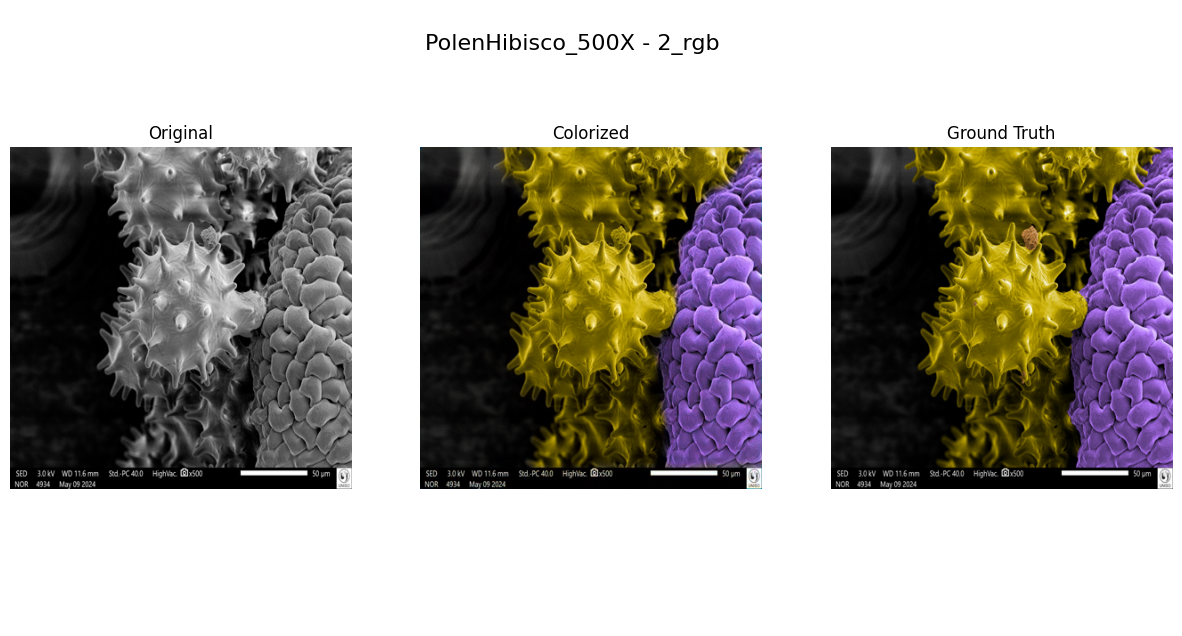

In [33]:
img = random.choice(test_images)

colorize(model, 
         img,
         experiment_path=experiment_path,
         save=True)